# Exercício Regressão Linear com PyTorch

Este notebook é um exercício baseado no notebook:
- [LinearRegressionIrisNumPy.ipynb](LinearRegressionIrisNumPy.ipynb) feito em NumPy,

O objetivo desse notebook é reescrevê-lo porém utilizando tensores do PyTorch.

Os nomes das funções do PyTorch são próximas das funções do Torch original escrito
na linguagem Lua, porém não são iguais.

## Importação dos pacotes

In [ ]:
# Instalar pacotes necessários (sem o erro de 'install')
!pip install -q wheel setuptools packaging torch torchvision torchaudio

# Importar PyTorch e verificar versão
import torch
print("Versão do PyTorch:", torch.__version__)

# Obter informações da plataforma de forma moderna
import sysconfig
platform = sysconfig.get_platform()
print("Plataforma:", platform)

# Detectar se há GPU disponível
accelerator = "cuda" if torch.cuda.is_available() else "cpu"
print("Acelerador:", accelerator)


Versão do PyTorch: 2.8.0+cu126
Plataforma: linux-x86_64
Acelerador: cpu


In [ ]:
%matplotlib inline
import torch

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

def print_assert(r):
    if r:
        return 'OK!'
    else:
        return 'Incorreto!'

## Dataset

### Leitura dos dados

In [ ]:
import pandas as pd
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_in = data[:,0:1]
y_in = data[:,1:2]

x_train = torch.FloatTensor(x_in)
y_train = torch.FloatTensor(y_in)

n_samples = x_train.size(0)
print('x_train.shape:',x_train.shape, type(x_train))
print('y_train.shape:',y_train.shape, type(y_train))

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

iris_pd = pd.DataFrame(x_in, columns=['x_in'])
iris_pd['y_in'] = y_in
iris_pd.head()

x_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
y_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
x_train[:5]:
 tensor([[7.0000],
        [6.4000],
        [6.9000],
        [5.5000],
        [6.5000]])
y_train[:5]:
 tensor([[4.7000],
        [4.5000],
        [4.9000],
        [4.0000],
        [4.6000]])


,x_in,y_in
0,7.0,4.7
1,6.4,4.5
2,6.9,4.9
3,5.5,4.0
4,6.5,4.6


### Normalização dos dados

Text(0, 0.5, 'Comprimento petalas')

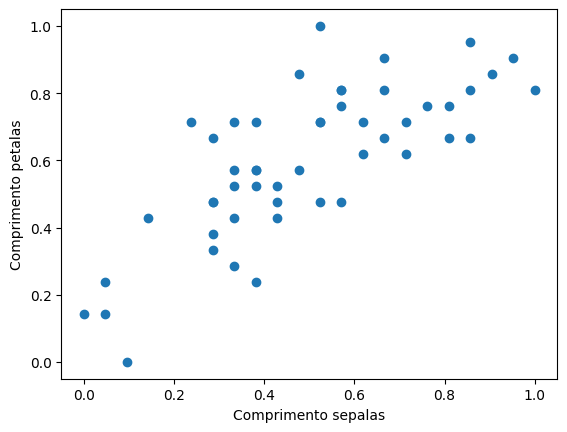

In [ ]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

### Exercício 1 - criação do `x_train_bias`

faça o `x_train_bias` ser uma matriz com 1s na primeira coluna e x_train na segunda coluna.




Dica: você pode precisar da função [torch.cat](http://pytorch.org/docs/master/torch.html#torch.cat) e [torch.ones](http://pytorch.org/docs/master/torch.html#torch.ones).

In [ ]:
import torch

# Exemplo: suponha que x_train seja um vetor de n_samples
n_samples = x_train.shape[0]

# Garante que x_train seja uma matriz coluna (n_samples x 1)
x_train = x_train.view(n_samples, 1)

# Cria a primeira coluna de 1s e concatena com x_train
x_train_bias = torch.cat((torch.ones(n_samples, 1), x_train), dim=1)

print(x_train_bias.size())
print(x_train_bias[:5])  # mostra as 5 primeiras linhas para conferir


torch.Size([50, 2])
tensor([[1.0000, 1.0000],
        [1.0000, 0.7143],
        [1.0000, 0.9524],
        [1.0000, 0.2857],
        [1.0000, 0.7619]])


In [ ]:
# Verificação do exercício - Execute para testar sua implementação

print('x_train_bias é um tensor: {}'.format(print_assert(
    isinstance(x_train_bias, torch.FloatTensor)
)))


print('tamanho do x_train_bias: {}'.format(print_assert(
    x_train_bias.size() == torch.Size([50, 2])
)))

print('primeira coluna é só de uns: {}'.format(print_assert(
    (x_train_bias[:, 0] - torch.ones(n_samples)).sum() == 0
)))

print('segunda coluna é igual a x_train: {}'.format(print_assert(
    (x_train_bias[:, 1] - x_train.reshape(50)).sum() == 0
)))


x_train_bias é um tensor: OK!
tamanho do x_train_bias: OK!
primeira coluna é só de uns: OK!
segunda coluna é igual a x_train: OK!


In [ ]:
print(x_train_bias[:, 1].shape)
print(x_train.shape)

torch.Size([50])
torch.Size([50, 1])


## Modelo da rede

### Definição da classe

In [ ]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = torch.Tensor(n_out, n_in)
        self.w.uniform_(-0.1,0.1) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.matmul(torch.t(self.w)) ## AQUI


### Instanciando a rede

In [ ]:
model = Net(2,1)

### Testando o predict da rede

In [ ]:
model.forward(torch.ones((4,2)))
#model.forward(torch.randn(4,2))

tensor([[-0.1138],
        [-0.1138],
        [-0.1138],
        [-0.1138]])

## Treinamento

### Exercício 2 - Treinamento

Refaça o código de treinamento da rede, mas agora utilizando somente Tensores do PyTorch. Faça o mesmo procedimento que o notebook [LinearRegressionIrisNumPy](LinearRegressionIrisNumPy.ipynb). Para consultar as operações disponíveis no PyTorch use a [documentação do PyTorch](http://pytorch.org/docs/master/torch.html).

Funções que podem ser úteis:
- torch.t
- torch.mean
- torch.matmul

In [ ]:
import torch

# Suponha que já temos x_train_bias e y_train como tensores do PyTorch
# Dimensões:
# x_train_bias: (n amostras, 2) -> primeira coluna = 1s (bias), segunda coluna = valores de x
# y_train: (n amostras, 1)

n_samples = x_train_bias.shape[0]

# Inicialização dos pesos (2 parâmetros: bias e coeficiente)
model = torch.nn.Linear(in_features=2, out_features=1, bias=False)
# Substituímos o bias interno por uma matriz de pesos única
model.w = torch.randn(1, 2, dtype=torch.float32)

# Hiperparâmetros
num_epochs = 100
learning_rate = 0.5

for epoch in range(num_epochs):
    # ---------- Forward ----------
    # y_pred = X * w^T
    y_pred = torch.matmul(x_train_bias, model.w.t())

    # ---------- Loss ----------
    loss = torch.mean((y_pred - y_train) ** 2)

    # ---------- Gradiente ----------
    # Fórmula: (2/n) * X^T * (Xw - y)
    w_grad = (2.0 / n_samples) * torch.matmul(x_train_bias.t(), (y_pred - y_train))

    # ---------- Atualização dos pesos ----------
    model.w = model.w - learning_rate * w_grad.t()

    # ---------- Verbose ----------
    if (epoch + 1) % 20 == 0:
        print(f"Epoch[{epoch+1}/{num_epochs}], loss: {loss.item():.6f}")


Epoch[20/100], loss: 0.021382
Epoch[40/100], loss: 0.021200
Epoch[60/100], loss: 0.021174
Epoch[80/100], loss: 0.021170
Epoch[100/100], loss: 0.021170


### Valor ótimo, solução analítica

## Avaliação

### Predict

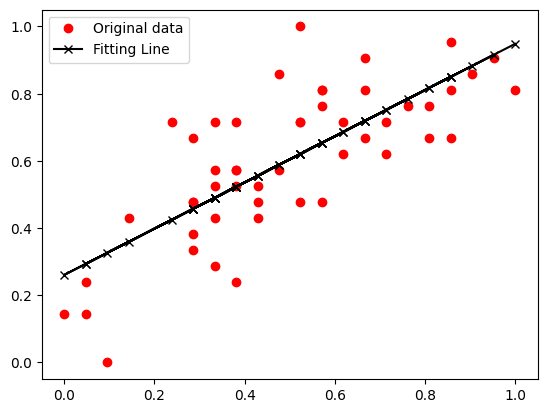

In [ ]:
import matplotlib.pyplot as plt

# Predição com os pesos finais
y_pred = torch.matmul(x_train_bias, model.w.t())

# Plot dos dados originais e da reta ajustada
plt.plot(x_train.numpy(), y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train.numpy(), y_pred.detach().numpy(), 'kx-', label='Fitting Line')
plt.legend()
plt.show()


### Parâmetro treinado

In [ ]:
print(model.w)

tensor([[0.2607, 0.6877]])


In [ ]:
x_bias = x_train_bias
y = y_train
w_opt = (torch.inverse(x_bias.t().mm(x_bias)).mm(x_bias.t())).mm(y)
print(w_opt.t())

tensor([[0.2613, 0.6865]])
